# Criterion Distribution

How often each of the 13 canonical criteria appears across the 6,612 LLM-extracted rules in `rules_classified_v18.tsv`.

Each rule can be tagged with **multiple criteria** (e.g. *Adult male citizens* → Gender + Citizenship + Age), so rule counts here sum to more than the total number of rules. Rules with no matching criterion are labelled `(none)`.

In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

RULES_TSV = Path('../data/rules_classified_v18.tsv')
df = pd.read_csv(RULES_TSV, sep='\t')
print(f'Total rules: {len(df):,}')

Total rules: 6,612


In [2]:
EXCLUDE = {'(none)', 'Legal Standing'}

counts = Counter()
for s in df['criteria'].fillna(''):
    cs = [c for c in s.split('|') if c and c not in EXCLUDE]
    counts.update(cs)

series = pd.Series(counts).sort_values(ascending=True)
series

Education               169
Health                  194
Nobility                314
Ethnicity               357
Religion                372
Lineage                 502
Freedom                 507
Wealth / Properties     558
Age                     841
Citizenship            1059
Gender                 1100
Occupation             1321
dtype: int64

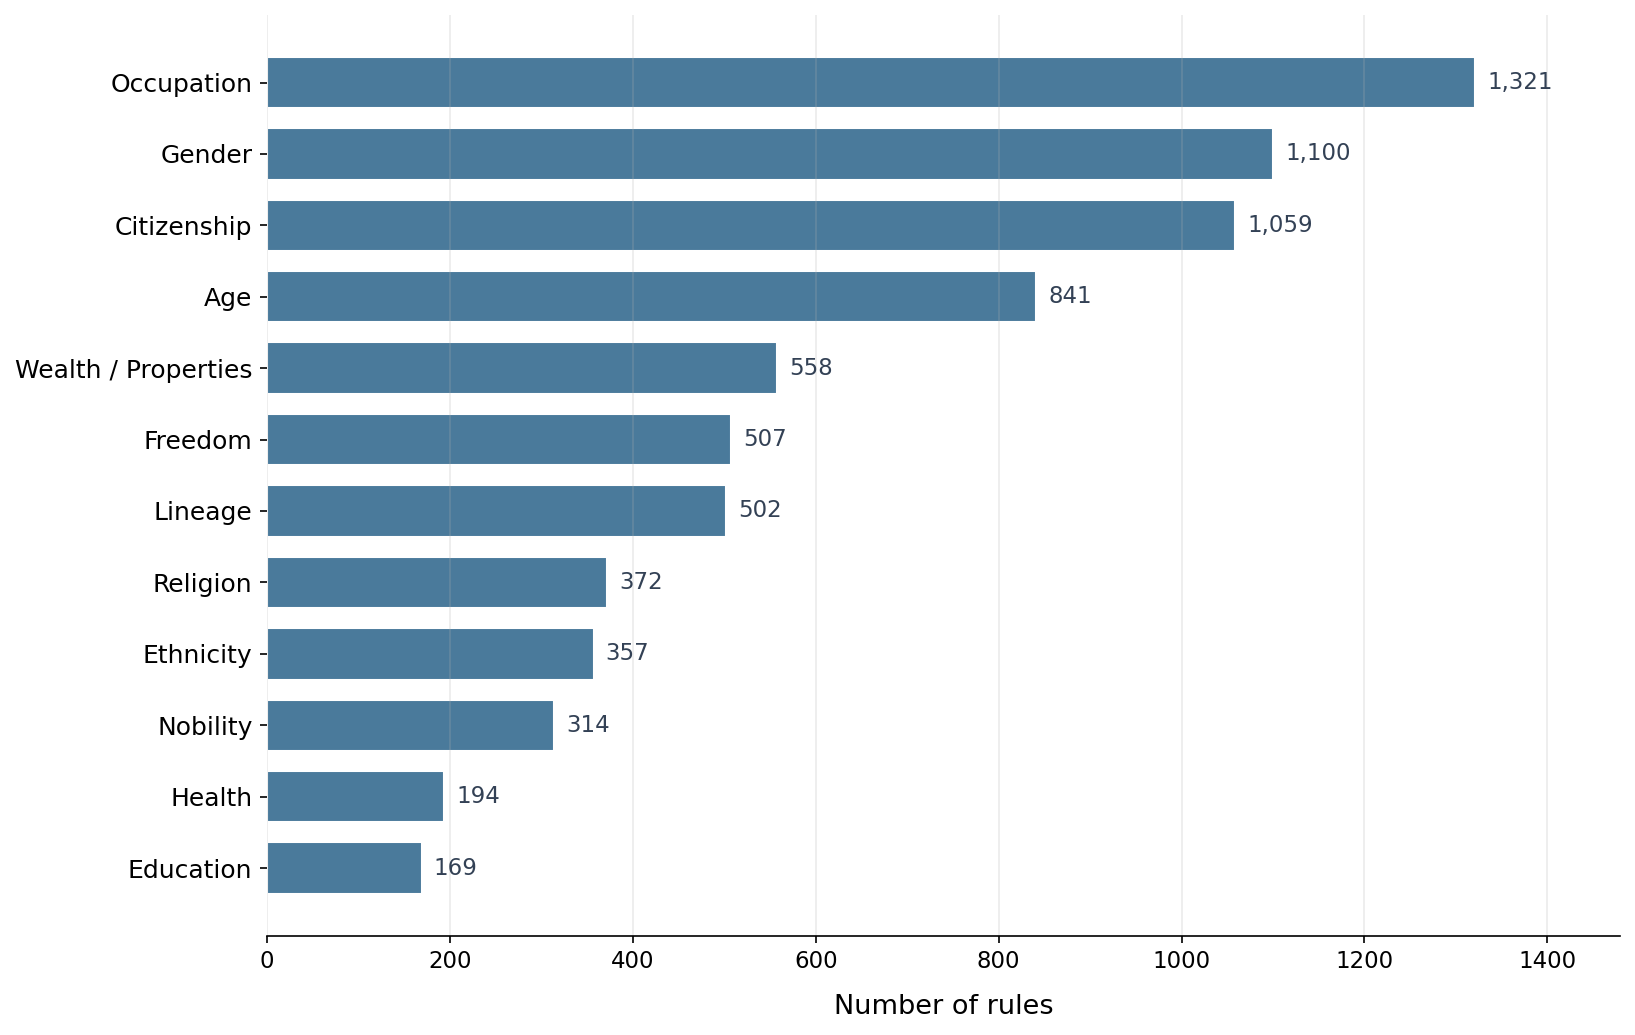

In [3]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(series.index, series.values, color='#4a7a9b', edgecolor='white', height=0.72)

for i, (lbl, v) in enumerate(series.items()):
    ax.text(v + max(series.values) * 0.01, i, f'{v:,}',
            va='center', fontsize=11, color='#334155')

ax.set_xlabel('Number of rules', fontsize=13, labelpad=10)
ax.set_xlim(0, max(series.values) * 1.12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='x', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

## Positive vs. negative resource by criterion

Same criteria, but each bar is split by `directionality` — rules granting a **positive resource** (blue, right) vs. a **negative resource** (red, left). Plotted as a diverging bar chart.

In [4]:
dir_counts = {c: {'MORE': 0, 'LESS': 0} for c in series.index}
for _, row in df[['criteria', 'directionality']].dropna(subset=['directionality']).iterrows():
    d = str(row['directionality']).strip().upper()
    if d not in ('MORE', 'LESS'):
        continue
    for c in str(row['criteria']).split('|'):
        if c in dir_counts:
            dir_counts[c][d] += 1

dir_df = pd.DataFrame(dir_counts).T
dir_df['total'] = dir_df['MORE'] + dir_df['LESS']
dir_df = dir_df.sort_values('total', ascending=True)
dir_df

,MORE,LESS,total
Education,71,98,169
Health,104,90,194
Nobility,241,73,314
Ethnicity,179,178,357
Religion,158,214,372
Lineage,330,172,502
Freedom,158,349,507
Wealth / Properties,263,295,558
Age,431,410,841
Citizenship,635,424,1059


/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_94653/1108193614.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{int(abs(t)):,}' for t in ticks], fontsize=10)


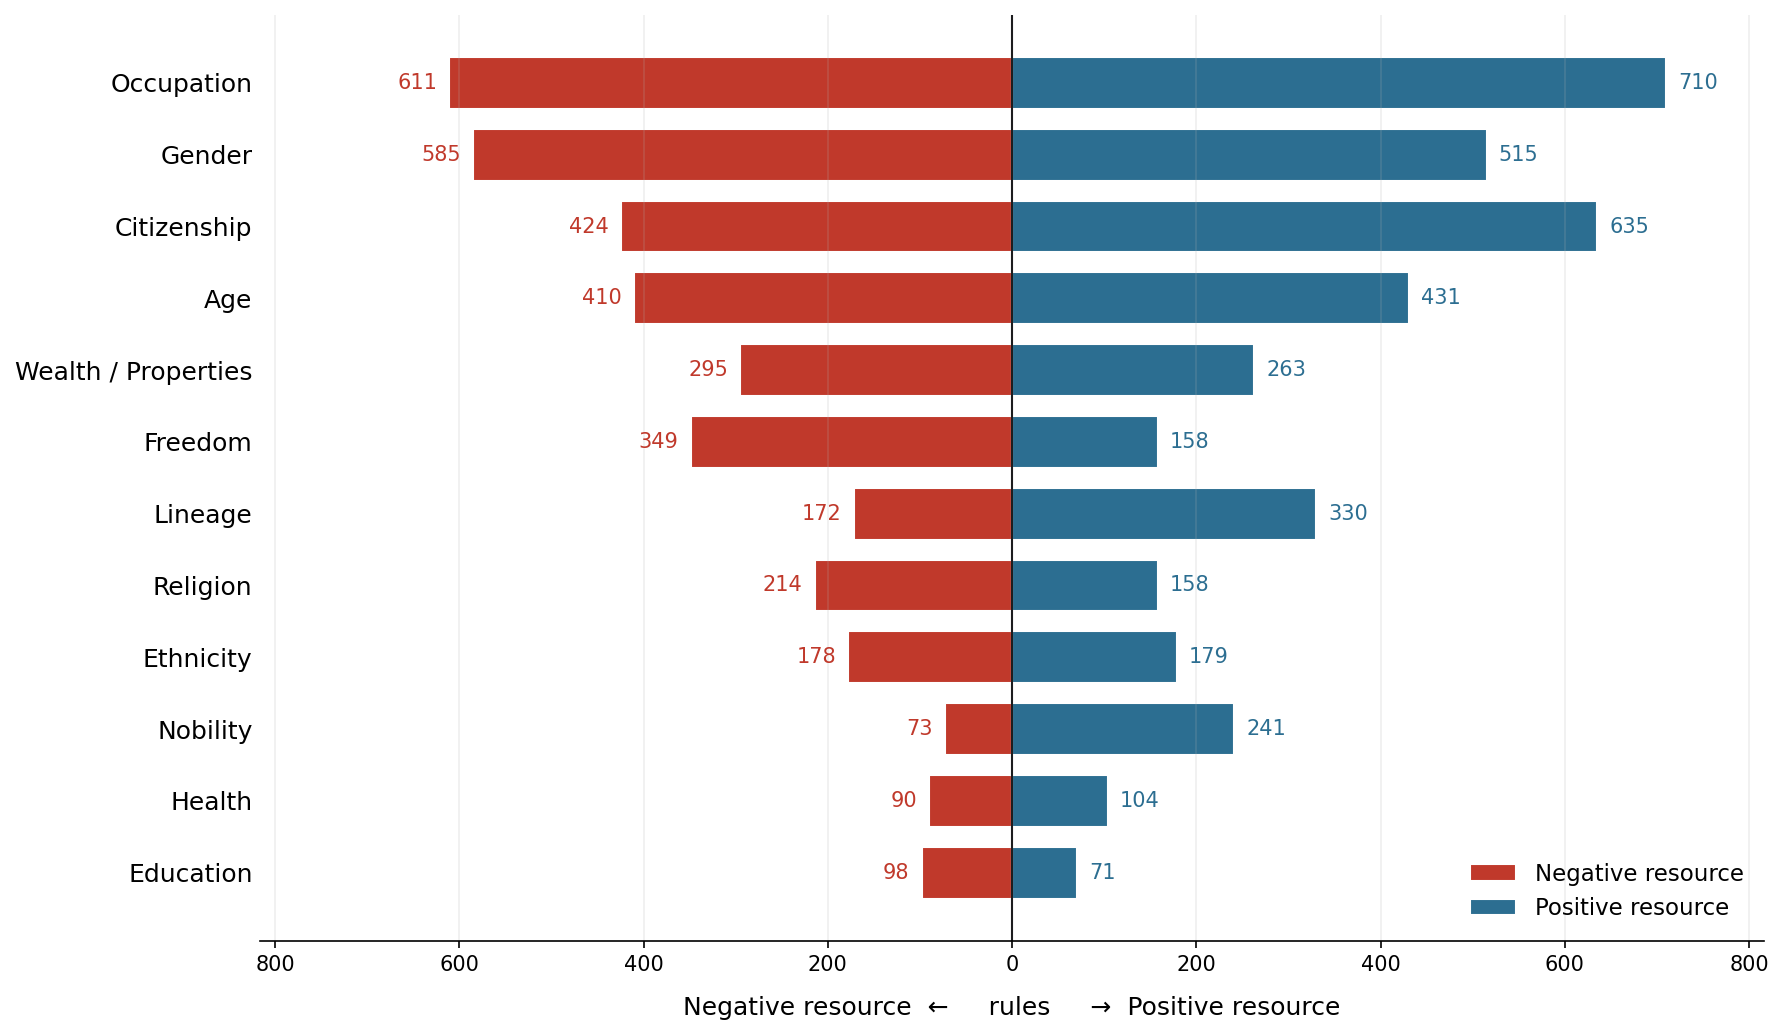

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

pos_color = '#2c6e91'
neg_color = '#c0392b'
y = range(len(dir_df))

ax.barh(y, -dir_df['LESS'], color=neg_color, edgecolor='white', height=0.72, label='Negative resource')
ax.barh(y,  dir_df['MORE'], color=pos_color, edgecolor='white', height=0.72, label='Positive resource')

for i, (lbl, row) in enumerate(dir_df.iterrows()):
    if row['LESS'] > 0:
        ax.text(-row['LESS'] - max(dir_df['total']) * 0.01, i, f"{int(row['LESS']):,}",
                ha='right', va='center', fontsize=10, color=neg_color)
    if row['MORE'] > 0:
        ax.text(row['MORE'] + max(dir_df['total']) * 0.01, i, f"{int(row['MORE']):,}",
                ha='left', va='center', fontsize=10, color=pos_color)

ax.set_yticks(list(y))
ax.set_yticklabels(dir_df.index, fontsize=12)
ax.axvline(0, color='#1d1d1f', linewidth=1)
ax.set_xlabel('Negative resource  \u2190     rules     \u2192  Positive resource', fontsize=12, labelpad=10)

mv = max(dir_df['LESS'].max(), dir_df['MORE'].max())
ax.set_xlim(-mv * 1.15, mv * 1.15)
ticks = ax.get_xticks()
ax.set_xticklabels([f'{int(abs(t)):,}' for t in ticks], fontsize=10)

ax.tick_params(axis='y', length=0)
ax.grid(axis='x', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.legend(loc='lower right', frameon=False, fontsize=11)
plt.tight_layout()
plt.show()